In [13]:
import pykasso as pk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import plotly.graph_objects as go
import networkx as nx
import importlib
import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages
# import cfpy

In [41]:
import utils.common
import utils.conduits
importlib.reload(utils.common)
importlib.reload(utils.conduits)
from utils.common import *
from utils.geos import * 
from utils.conduits import *

In [15]:
import bear_spring_pykasso_settings
importlib.reload(bear_spring_pykasso_settings)
from bear_spring_pykasso_settings import *

# Generate Single Straight Line Conduit

In [63]:
nodes = pd.read_csv('../../data/networks/single_conduit/nodes_simplified.csv')
nodes = nodes[(nodes.type == 'inlet') | (nodes.type == 'outlet')]
nodes = nodes.drop('id', axis=1).reset_index(drop=True).reset_index().rename(columns={'index':'id'})
edges = pd.DataFrame(columns = ['from_id', 'to_id'])
edges[['from_id', 'to_id']] = [[0,1]]
edges = extract_edge_coordinates(nodes, edges)
dense_nodes, dense_edges = densify_edges(nodes, edges, density_factor = 60)
dense_nodes.to_csv('../../data/networks/single_conduit/straight_conduit_n62/nodes.csv', index=False)
dense_edges.to_csv('../../data/networks/single_conduit/straight_conduit_n62/edges.csv', index=False)

In [65]:
plot_3D_network(dense_nodes, dense_edges)

## Generate Network with PyKasso

In [4]:
app = pk.pykasso()
# Create a new project and declare its parameters
app.new_project(name=name, grid_parameters=grid_parameters)
app.visualizer.notebook = True
nx, ny, nz = app.project.grid.shape

In [5]:
top =np.load('../../data/DEM/dem_grid_bear_spring.npy').T
model_parameters['domain']['topography'] = top

In [6]:
app.model.grid

Grid(x0=557546.0, y0=4867231.0, z0=370.0, nx=588, ny=475, nz=6, dx=5.0, dy=5.0, dz=5.0)

In [7]:
model_parameters['domain']['topography'].min()

np.float32(371.167)

In [8]:
for i in range(1):
    app.model.generate(model_parameters)
    # print(app.model.model_parameters['sks']['seed'])


In [9]:
edges = pd.DataFrame.from_dict(app.model.vectors['edges'], orient = 'index')
nodes = pd.DataFrame.from_dict(app.model.vectors['nodes'], orient ='index')
nodes.columns = ['x', 'y', 'z', 'type']
nodes = nodes.reset_index().rename({'index':'id'}, axis=1)
edges.columns = ['from_id', 'to_id']

In [10]:
# nodes = pd.read_csv("../../data/networks/conduit_activation/nodes.csv").dropna()
# edges = pd.read_csv("../../data/networks/conduit_activation/edges.csv").dropna()
# nodes['id'] = nodes.id.astype(int)
# edges['from_id'] = edges.from_id.astype(int)
# edges['to_id'] = edges.to_id.astype(int)

In [ ]:

lines = edges[["x_0", "y_0", "z_0", "x_1", "y_1", "z_1"]].values
lines = lines.reshape(-1, 2, 3)

<Axes: xlabel='x', ylabel='z'>

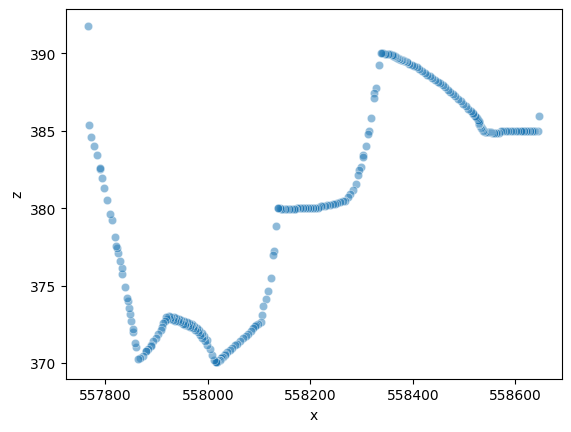

In [11]:
sns.scatterplot(nodes, x='x', y='z', alpha = 0.5)

In [ ]:
app.project._get_simulation_data(11)['maps']['karst']

1

In [12]:
import plotly.graph_objects as go
line_traces = []
for line in lines:
    line_traces.append(
        go.Scatter3d(
            x=line[:,0],
            y=line[:,1],
            z=line[:,2],
            mode='lines',
            line=dict(color='blue', width=1),
            showlegend=False
        )
    )
node_type_map = {cat: i for i, cat in enumerate(nodes.type.unique())}
node_colors = nodes.type.map(node_type_map)
# Scatter for nodes
scatter = go.Scatter3d(
    x=nodes.x,
    y=nodes.y,
    z=nodes.z,
    mode='markers',
    marker=dict(
        size=5,
        color=node_colors,  # categorical or numeric
        colorscale='Viridis',
        showscale=True
    )
)

# Combine and plot
fig = go.Figure(data=line_traces + [scatter])
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

## Quantify 